In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

# Step 1: 读取数据 Read Data
file_path = r"final_merged_data.csv"
df = pd.read_csv(file_path)

# 需要分析的变量 Variables to be analyzed
columns = ['TREFMXAV_U','FLNS','FSNS','PRECT','PRSN','QBOT','TREFHT','UBOT','VBOT']
 
# 统计缺失值数量 Count the number of missing values
missing_counts = df[columns].isnull().sum()

print("Count of missing values：")
for col in columns:
    print(f"{col} {missing_counts[col]}")


Count of missing values：
TREFMXAV_U 3941856
FLNS 0
FSNS 0
PRECT 0
PRSN 0
QBOT 0
TREFHT 0
UBOT 0
VBOT 0


Missing: 3941856
Non-missing: 6898248


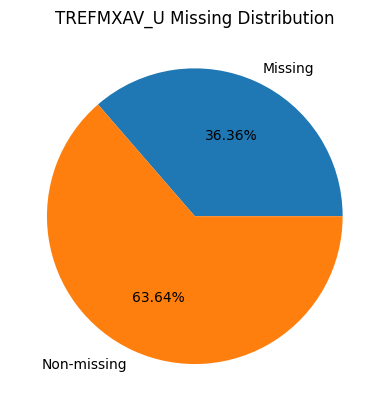

In [100]:
# Step 1.5 : 给TREFMXAV_U绘制缺失饼状图 Draw a pie chart for the missing values of TREFMXAV_U

col = 'TREFMXAV_U'

# 统计缺失值 Statistical missing values
missing = df[col].isnull().sum()
non_missing = df[col].notnull().sum()

print("Missing:", missing)
print("Non-missing:", non_missing)


#画饼图 Draw pie chart
plt.figure()
plt.pie(
    [missing, non_missing],
    labels=['Missing', 'Non-missing'],
    autopct='%1.2f%%'
)
plt.title('TREFMXAV_U Missing Distribution')
plt.show()

In [101]:
# Step 2: 温度转换 Temperature conversion

df['TREFMXAV_U'] = df['TREFMXAV_U'] - 273.15
df['TREFHT'] = df['TREFHT'] - 273.15

print("\n已完成温度转换（K → °C）")


已完成温度转换（K → °C）


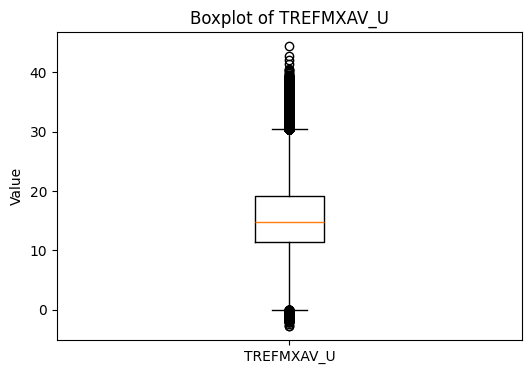

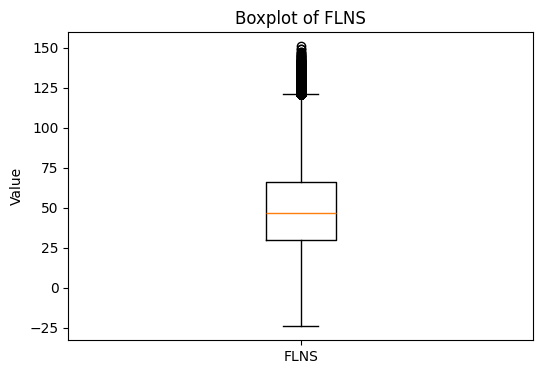

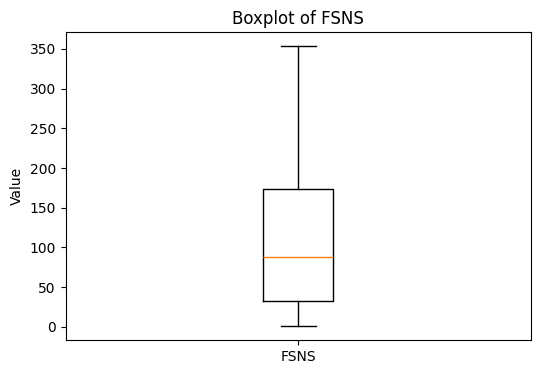

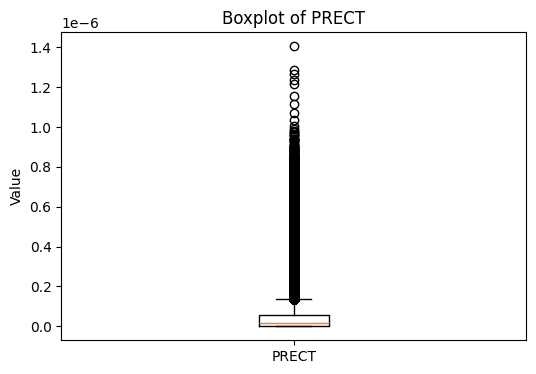

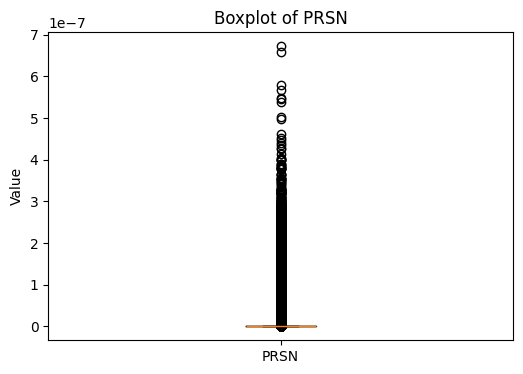

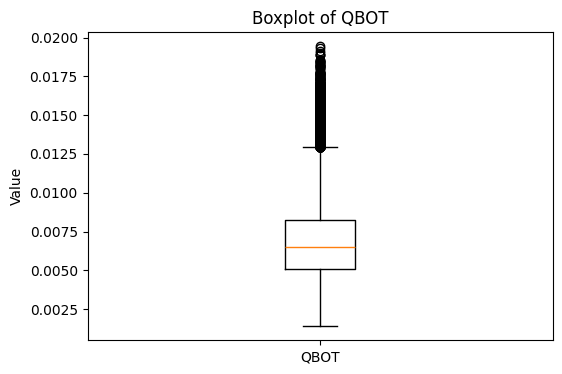

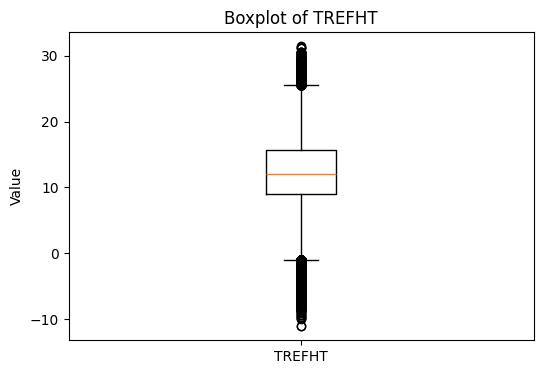

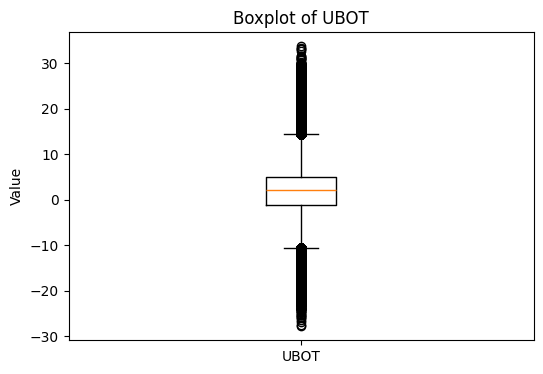

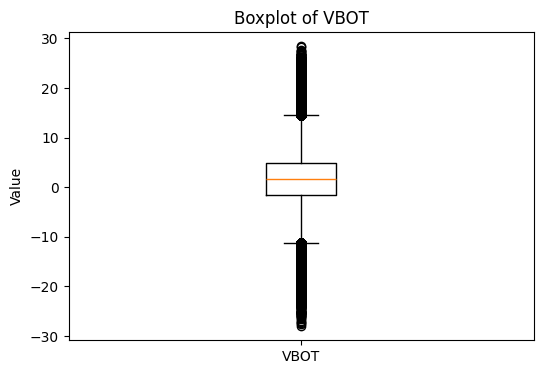

In [102]:
# Step 3: 绘制箱型图（全部未处理信息）Draw a box plot (including all unprocessed data): 

cols = ['TREFMXAV_U','FLNS','FSNS','PRECT','PRSN','QBOT','TREFHT','UBOT','VBOT']

for col in cols:
    plt.figure(figsize=(6,4))
    
    plt.boxplot(df[col].dropna())
    
    # 修改x轴标签 Modify the label of the x-axis
    plt.xticks([1], [col])
    
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Value')
    
    plt.show()

In [103]:
# Step 5: 统计明显错误值的数量 Count the number of significant error values
# 创建异常掩码 Create exception mask
print("QBOT < 0:", (df['QBOT'] < 0).sum())
print("PRECT < 0:", (df['PRECT'] < 0).sum())
print("PRSN < 0:", (df['PRSN'] < 0).sum())

print("TREFMXAV_U extreme:", ((df['TREFMXAV_U'] < -20) | (df['TREFMXAV_U'] > 40)).sum())
print("TREFHT extreme:", ((df['TREFHT'] <-20) | (df['TREFHT'] > 40)).sum())

print("QBOT too large:", (df['QBOT'] > 0.03).sum())

print("PRECT too large:", (df['PRECT'] > 1e-4).sum())
print("PRSN too large:", (df['PRSN'] > 1e-4).sum())

print("UBOT extreme:", ((df['UBOT'] > 40) | (df['UBOT'] < -40)).sum())
print("VBOT extreme:", ((df['VBOT'] > 40) | (df['VBOT'] < -40)).sum())

print("FLNS extreme:", (df['FLNS'].abs() > 300).sum()) #晚间辐射低 Low evening radiation
print("FSNS extreme:", (df['FSNS'].abs() > 500).sum()) #早晨辐射高 High radiation in the morning


QBOT < 0: 0
PRECT < 0: 584
PRSN < 0: 411261
TREFMXAV_U extreme: 8
TREFHT extreme: 0
QBOT too large: 0
PRECT too large: 0
PRSN too large: 0
UBOT extreme: 0
VBOT extreme: 0
FLNS extreme: 0
FSNS extreme: 0


In [104]:
# Step 5.5: 直接删除明显错误值 Directly replace the obviously incorrect values with NaN

# QBOT
df.loc[(df['QBOT'] < 0) | (df['QBOT'] > 0.03), 'QBOT'] = np.nan

# PRECT 和 PRSN
df.loc[(df['PRECT'] < 0), 'PRECT'] = np.nan
df.loc[(df['PRSN'] < 0), 'PRSN'] = np.nan

# 温度 Temperature
df.loc[(df['TREFMXAV_U'] < -20) | (df['TREFMXAV_U'] > 40), 'TREFMXAV_U'] = np.nan
df.loc[(df['TREFHT'] < -20) | (df['TREFHT'] > 40), 'TREFHT'] = np.nan

# 风速 Wind
df.loc[(df['UBOT'] > 40) | (df['UBOT'] < -40), 'UBOT'] = np.nan
df.loc[(df['VBOT'] > 40) | (df['VBOT'] < -40), 'VBOT'] = np.nan

# 辐射 Radiation
df.loc[df['FLNS'].abs() > 300, 'FLNS'] = np.nan
df.loc[df['FSNS'].abs() > 500, 'FSNS'] = np.nan

# 检查 NaN 数量 Count NaN（注：TREFMXAV_U的NaN来自缺失值较多，经比对此为与异常值和）
# PS: The NaN value of TREFMXAV_U is due to a large number of missing values. After comparing it with outliers and other factors, this conclusion was reached.
nan_counts = df[['PRECT', 'PRSN', 'TREFMXAV_U']].isna().sum()
print(nan_counts)

PRECT             584
PRSN           411261
TREFMXAV_U    3941864
dtype: int64


In [105]:

# Step 6: 时间特征 time characteristics

df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['dayofyear'] = df['time'].dt.dayofyear

print("\n时间特征已添加：year, month, dayofyear")


时间特征已添加：year, month, dayofyear


In [106]:
# Step 7: 导出为 parquet格式 Export as Parquet format
df.to_parquet("processed_data_project_2.parquet")

In [107]:
# Step 8: 最终检验是否成功 Test whether the final inspection was successful
df = pd.read_parquet("processed_data_project_2.parquet")
df['member_id'].value_counts()
table = pq.ParquetFile("processed_data_project_2.parquet")
num_rows = table.metadata.num_rows
print(num_rows)

10840104


In [108]:
df = pd.read_parquet("processed_data_project_2.parquet")
df.head(15)

,time,lat,lon,TREFMXAV_U,FLNS,FSNS,PRECT,PRSN,QBOT,TREFHT,UBOT,VBOT,member_id,year,month,dayofyear
0,2006-01-02,49.476440,352.50,NaN,76.479730,44.470936,1.157632e-08,0.000000e+00,0.005241,11.20727,7.604368,-3.689787,3,2006,1,2
1,2006-01-02,49.476440,353.75,NaN,78.499650,47.310978,1.511678e-08,5.754220e-23,0.005230,11.01160,6.998310,-4.547439,3,2006,1,2
2,2006-01-02,49.476440,355.00,NaN,79.779884,47.081330,1.400193e-08,2.408303e-23,0.005142,10.72620,6.095287,-4.407815,3,2006,1,2
3,2006-01-02,49.476440,356.25,NaN,81.951940,50.421570,1.458893e-08,3.645272e-18,0.005161,10.40737,5.727140,-3.411074,3,2006,1,2
4,2006-01-02,49.476440,357.50,NaN,84.151150,50.305706,1.563543e-08,1.291952e-17,0.005128,10.02792,5.714839,-2.058823,3,2006,1,2
5,2006-01-02,49.476440,358.75,10.52900,78.309050,49.704235,1.521918e-08,2.044216e-17,0.005410,8.23837,5.109643,-0.435289,3,2006,1,2
6,2006-01-02,50.418850,352.50,NaN,71.069230,38.477320,1.399889e-08,0.000000e+00,0.005202,10.78286,7.924366,-2.245590,3,2006,1,2
7,2006-01-02,50.418850,353.75,NaN,74.815140,42.199245,1.338713e-08,2.912953e-18,0.005100,10.59066,7.270111,-3.232553,3,2006,1,2
8,2006-01-02,50.418850,355.00,11.29394,78.301250,44.980167,1.131585e-08,8.991746e-22,0.005035,9.92712,6.209209,-3.468437,3,2006,1,2
9,2006-01-02,50.418850,356.25,11.17986,82.156400,46.794003,8.339057e-09,1.546433e-20,0.005278,9.32390,5.486755,-2.518895,3,2006,1,2
